13
{'Antonio López', 'Koke Resurrección', 'Juanfran Torres', 'Diego Godín', 'Juan Valera', 'Luis Perea'}
17
{'Albert Jorquera', 'Andrés Iniesta', 'Lionel Messi'}


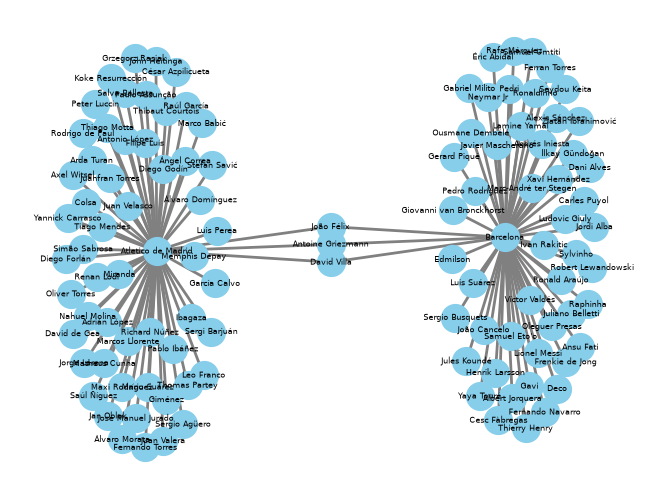

In [18]:
from collections import defaultdict
import os
import pandas as pd

import networkx as nx
import matplotlib.pyplot as plt

def cargar_relacion(ruta, club):
    listaJugadores = defaultdict(list)

    for archivo in os.listdir(ruta):
        temporada = archivo.replace(".csv", "").replace("atletico_", "")
        df = pd.read_csv(os.path.join(ruta, archivo))

        for jugador in df["jugador"].dropna():
            listaJugadores[str(jugador)].append((club, temporada))

    return listaJugadores

#diccionarioAtletico
relacionA = cargar_relacion("../datasets/equipoA", "Atletico de Madrid")
#diccionarioBarcelona
relacionB = cargar_relacion("../datasets/equipoB", "Barcelona")

#construir tabla con Pandas

filas = []

for relacion in [relacionA, relacionB]:
    for jugador, relaciones in relacion.items():
        club = relaciones[0][0]
        temporadas = [temporada for _, temporada in relaciones]

        filas.append({
            "Jugador": jugador,
            "Club": club,
            "Temporadas": ", ".join(temporadas)
        })

tabla = pd.DataFrame(filas)

#construimos el grafo

G = nx.Graph()

def añadir_relaciones(G, relacion):
    for jugador, relaciones in relacion.items():
        G.add_node(jugador, tipo="jugador")

        for club, temporada in relaciones:
            G.add_node(club, tipo="club")

            if G.has_edge(jugador, club):
                G[jugador][club]["temporadas"].append(temporada)
            else:
                G.add_edge(
                    jugador,
                    club,
                    temporadas=[temporada]
                )

añadir_relaciones(G, relacionA)
añadir_relaciones(G, relacionB)

nx.draw(
    G,
    pos=nx.spring_layout(G),  # Layout positions for nodes
    with_labels=True,         # Display node labels
    node_color='skyblue',     # Node fill color
    node_size=400,            # Node size in points^2
    font_size=6,             # Label font size
    font_color='black',       # Label font color
    edge_color='gray',        # Edge color
    width=2,                  # Edge line width
    style='solid',            # Edge line style ('solid', 'dashed', etc.)
)


#¿Qué jugadores tienen más temporadas?
maxTemporadasATL=0
maxTemporadasBAR=0
jugadoresMasTemporadasATL = set()
jugadoresMasTemporadasBAR = set()

for jugador in relacionA:
    for temporadas in relacionA[jugador]:
        if len(relacionA[jugador]) >= maxTemporadasATL:
            maxTemporadasATL = len(relacionA[jugador])
            jugadoresMasTemporadasATL.add(jugador)

for jugador in relacionB:
    for temporadas in relacionB[jugador]:
        if len(relacionB[jugador]) >= maxTemporadasBAR:
            maxTemporadasBAR = len(relacionB[jugador])
            jugadoresMasTemporadasBAR.add(jugador)

print(maxTemporadasATL)
print(jugadoresMasTemporadasATL)

print(maxTemporadasBAR)
print(jugadoresMasTemporadasBAR)